In [49]:
import sys
print(sys.executable)

C:\Users\HP\.conda\envs\env\python.exe


In [50]:
from pathlib import Path
DATA_DIR = Path("../data")
easy_ham = DATA_DIR / "20030228_easy_ham" / "easy_ham"
easy_ham2 = DATA_DIR / "20030228_easy_ham_2" / "easy_ham_2"
hard_ham = DATA_DIR / "20030228_hard_ham" / "hard_ham"

spam = DATA_DIR / "20030228_spam" / "spam"
spam2 = DATA_DIR / "20030228_spam_2" / "spam_2"

In [117]:
import email

def extract_body(email_text):
    try:
        msg = email.message_from_string(email_text)
        subject = msg.get("Subject", "")
        body = ""
        if msg.is_multipart():
            for part in msg.walk():
                content_type = part.get_content_type()
                content_disposition = str(part.get("Content-Disposition"))
                if content_type == "text/plain" and "attachment" not in content_disposition:
                    payload = part.get_payload(decode=True)
                    if payload:
                        body += payload.decode(part.get_content_charset() or 'latin1', errors='ignore')
        else:
            payload = msg.get_payload(decode=True)
            if payload:
                body = payload.decode(msg.get_content_charset() or 'latin1', errors='ignore')
        return f"{subject} {body}"
    except Exception:
        return email_text

#this is an function to load Emails
def load_emails(data):
    emails = []
    for file in data.iterdir():
        if file.name.startswith("."):
            continue
        with open(file,"r", encoding="latin1") as f:
            email_text = f.read()
        cleaned_text = extract_body(email_text)
        emails.append(cleaned_text)
    return emails

In [118]:
#load all the emails 
ham_easy=load_emails(easy_ham)
ham_easy2=load_emails(easy_ham2)
ham_hard=load_emails(hard_ham)
spam_1=load_emails(spam)
spam_2=load_emails(spam2)

#combine them 
ham_emails=ham_easy+ham_easy2+ham_hard
spam_emails=spam_1+spam_2

print("ham emails:",len(ham_emails))
print("spam emails:",len(spam_emails))

ham emails: 4153
spam emails: 1899


In [119]:
print(ham_emails[0])
print(spam_emails[0])
print("Total emails:", len(ham_emails) + len(spam_emails))

Re: New Sequences Window     Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>


  | I can't reproduce this error.

For me it is very repeatable... (like every time, without fail).

This is the debug log of the pick happening ...

18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...

Note, if I run the pick command by hand ...

delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hit

That's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...

delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.

In [120]:
X = ham_emails + spam_emails
y=[0]*len(ham_emails) + [1]*len(spam_emails)


In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [122]:
print(X_train[0])

=?big5?Q?=B3=D0=B7~=C2=E0=B7~=A4u=C5=AA=B7s=A6=E6=B7~=B6W=B0=D3=B3s=C2=EA=A5[=B7=F9?= 


In [123]:
#function to clean the data  for lowercase replace urls replace numbers remove punctuation remove extra spaces by using regular expression 

import re
import string
from bs4 import BeautifulSoup

def preprocess_email(text):
    try:
        # Strip HTML tags using BeautifulSoup
        text = BeautifulSoup(text, "html.parser").get_text()
    except Exception:
        pass
    text=text.lower()
    text=re.sub(r"https?://\S+","url",text)
    text=re.sub(r"\d+","NUMBER",text)
    text=text.translate(str.maketrans("","",string.punctuation))
    text=" ".join(text.split())
    return text

In [124]:
sample = X_train[0]

print("original:\n")
print(sample)

print("\n" + "="*60 + "\n")

print("processed:\n")
print(preprocess_email(sample))

original:

=?big5?Q?=B3=D0=B7~=C2=E0=B7~=A4u=C5=AA=B7s=A6=E6=B7~=B6W=B0=D3=B3s=C2=EA=A5[=B7=F9?= 


processed:

bigNUMBERqbNUMBERdNUMBERbNUMBERcNUMBEReNUMBERbNUMBERaNUMBERucNUMBERaabNUMBERsaNUMBEReNUMBERbNUMBERbNUMBERwbNUMBERdNUMBERbNUMBERscNUMBEReaaNUMBERbNUMBERfNUMBER


In [125]:
X_train_clean=[preprocess_email(email) for email in X_train]
X_test_clean = [preprocess_email(email) for email in X_test]


In [126]:
print(type(X_train_clean[0]))


<class 'str'>


In [127]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
X_train_vectorized=vectorizer.fit_transform(X_train_clean) #fit() reads every training email and builds vocabulary
X_test_vectorized = vectorizer.transform(X_test_clean)
print("training shape:", X_train_vectorized.shape)
print("testing shape:", X_test_vectorized.shape)

training shape: (4841, 64488)
testing shape: (1211, 64488)


In [128]:
feature_names = vectorizer.get_feature_names_out()

vector = X_train_vectorized[0]

for index, count in zip(vector.indices, vector.data):
    print(feature_names[index], ":", count)

bignumberqbnumberdnumberbnumbercnumberenumberbnumberanumberucnumberaabnumbersanumberenumberbnumberbnumberwbnumberdnumberbnumberscnumbereaanumberbnumberfnumber : 1


In [129]:
y_train
y_test

[0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,


In [130]:
from sklearn.naive_bayes import MultinomialNB
spam_classifier = MultinomialNB()
spam_classifier.fit(X_train_vectorized,y_train)
y_pred = spam_classifier.predict(X_test_vectorized)
print(y_pred[:10])
print(y_test[:10])


[0 1 0 0 0 0 0 0 0 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [131]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

precision=precision_score(y_test,y_pred)
print("precision:",precision)

recall=recall_score(y_test,y_pred)
print("Recall: ",recall)

f1= f1_score(y_test,y_pred)
print("f1->",f1)

confusion_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix score:",confusion_matrix)


Accuracy: 0.9777043765483072
precision: 0.9769452449567724
Recall:  0.946927374301676
f1-> 0.9617021276595744
confusion matrix score: [[845   8]
 [ 19 339]]


In [132]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       853
           1       0.98      0.95      0.96       358

    accuracy                           0.98      1211
   macro avg       0.98      0.97      0.97      1211
weighted avg       0.98      0.98      0.98      1211



In [133]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_vectorized, y_train)
y_pred_logistic = logistic_model.predict(X_test_vectorized)

In [134]:
nb_accuracy = accuracy_score(y_test, y_pred)
nb_precision = precision_score(y_test, y_pred)
nb_recall = recall_score(y_test, y_pred)
nb_f1 = f1_score(y_test, y_pred)

In [135]:
lr_accuracy = accuracy_score(y_test, y_pred_logistic)
lr_precision = precision_score(y_test, y_pred_logistic)
lr_recall = recall_score(y_test, y_pred_logistic)
lr_f1 = f1_score(y_test, y_pred_logistic)

In [136]:
import pandas as pd 
results=pd.DataFrame({
     "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1 Score": [nb_f1, lr_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.977704,0.976945,0.946927,0.961702
1,Logistic Regression,0.990917,0.977961,0.991620,0.984743


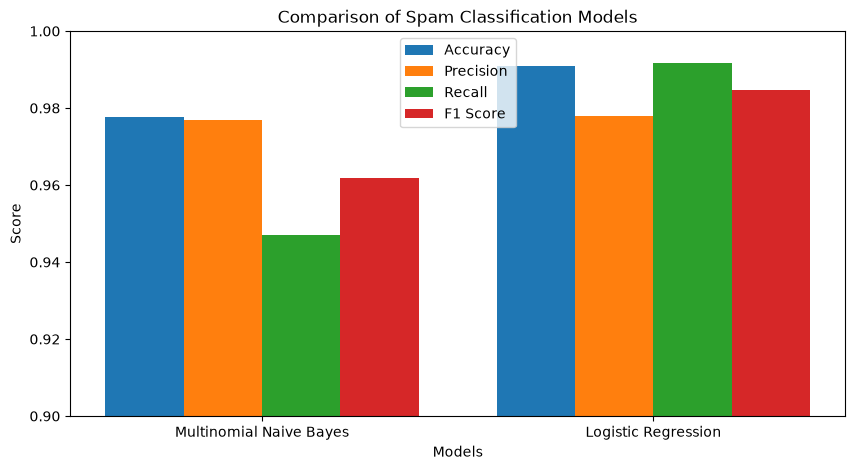

In [137]:
import matplotlib.pyplot as plt
import numpy as np

models = results["Model"]

accuracy = results["Accuracy"]
precision = results["Precision"]
recall = results["Recall"]
f1 = results["F1 Score"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,5))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)

plt.title("Comparison of Spam Classification Models")
plt.xlabel("Models")
plt.ylabel("Score")

plt.ylim(0.9, 1.0)

plt.legend()

plt.show()

In [138]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer()

# Fit on training data
X_train_tfidf = tfidf.fit_transform(X_train_clean)

# Transform test data
X_test_tfidf = tfidf.transform(X_test_clean)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4841, 64488)
(1211, 64488)


In [139]:
from sklearn.linear_model import LogisticRegression

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)

lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

In [140]:
from sklearn.naive_bayes import MultinomialNB

nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

In [141]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "Naive Bayes (Count)",
        "Logistic Regression (Count)",
        "Naive Bayes (TF-IDF)",
        "Logistic Regression (TF-IDF)"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_logistic),
        accuracy_score(y_test,y_pred_nb_tfidf),
        accuracy_score(y_test,y_pred_lr_tfidf)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_logistic),
        precision_score(y_test,y_pred_nb_tfidf),
        precision_score(y_test,y_pred_lr_tfidf)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_logistic),
        recall_score(y_test,y_pred_nb_tfidf),
        recall_score(y_test,y_pred_lr_tfidf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_logistic),
        f1_score(y_test,y_pred_nb_tfidf),
        f1_score(y_test,y_pred_lr_tfidf)
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes (Count),0.9777,0.9769,0.9469,0.9617
1,Logistic Regression (Count),0.9909,0.9780,0.9916,0.9847
2,Naive Bayes (TF-IDF),0.9108,1.0000,0.6983,0.8224
3,Logistic Regression (TF-IDF),0.9612,0.9785,0.8883,0.9312


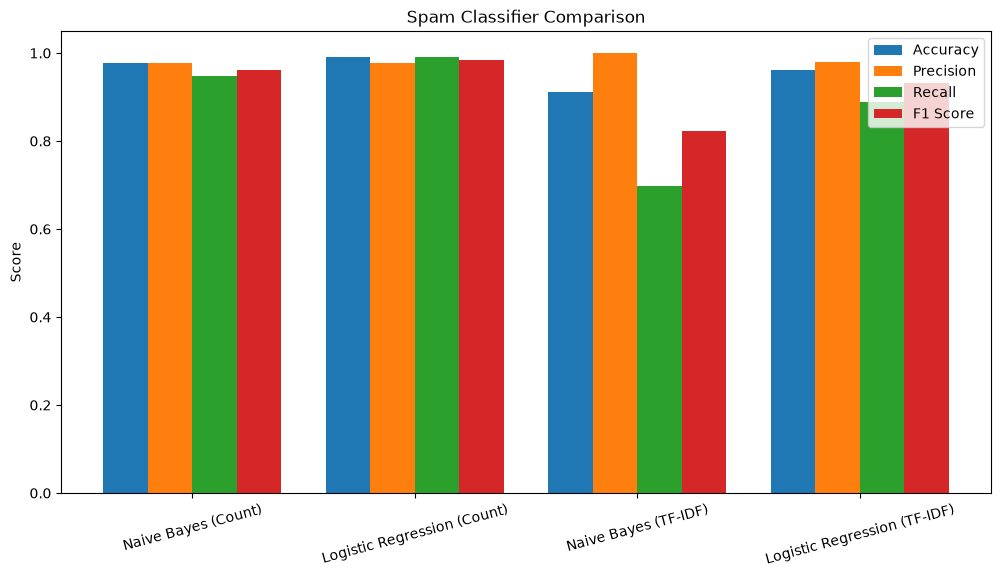

In [142]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison["Model"]

accuracy = comparison["Accuracy"]
precision = comparison["Precision"]
recall = comparison["Recall"]
f1 = comparison["F1 Score"]

x = np.arange(len(models))

width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x-1.5*width,accuracy,width,label="Accuracy")
plt.bar(x-0.5*width,precision,width,label="Precision")
plt.bar(x+0.5*width,recall,width,label="Recall")
plt.bar(x+1.5*width,f1,width,label="F1 Score")

plt.xticks(x,models,rotation=15)

plt.ylabel("Score")
plt.title("Spam Classifier Comparison")

plt.legend()

plt.show()

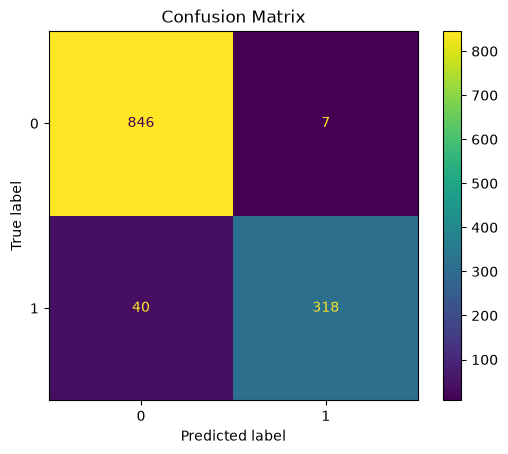

In [143]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_tfidf
)

plt.title("Confusion Matrix")

plt.show()

In [144]:
def predict_email(email):

    cleaned = preprocess_email(email)

    vector = tfidf.transform([cleaned])

    prediction = lr_tfidf.predict(vector)

    if prediction[0] == 1:
        return "Spam"

    return "Ham"

In [145]:
email = """
Congratulations!

You have won $5000.

Click here now

https://abc.com
"""

print(predict_email(email))

Spam


In [146]:
email = """
Subject: Sync Meeting Tomorrow at 10 AM

Hi Team,

Just a quick reminder that we have our weekly project sync meeting tomorrow at 10:00 AM in the main conference room. 

Please make sure to update your progress in the shared sheet before the meeting. Let me know if anyone has conflicts.

Best regards,
Nikhil
"""
print(predict_email(email))

Ham


In [147]:
# Import libraries
import joblib
from pathlib import Path

# Create the models directory path
MODELS_DIR = Path("../models")

# Create the folder if it doesn't exist
MODELS_DIR.mkdir(exist_ok=True)

# Save the trained Logistic Regression model
joblib.dump(
    lr_tfidf,
    MODELS_DIR / "spam_classifier.pkl"
)

# Save the TF-IDF vectorizer
joblib.dump(
    tfidf,
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [37]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")

# Load model
model = joblib.load(MODELS_DIR / "spam_classifier.pkl")

# Load vectorizer
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!
